# Autoencoder Training Notebook

This notebook runs the convolutional autoencoder training pipeline end to end on the processed WM-811K metadata and visualizes both the training curve and sample reconstructions.

Recommended usage:
- Start with `metadata_dev.csv`
- Confirm the pipeline and visuals
- Later switch the config to the full `metadata.csv` for serious experiments

In [16]:
from pathlib import Path
import json
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score
import torch
from torch.utils.data import DataLoader

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
REPO_ROOT = None
for candidate in candidate_roots:
    if (candidate / "src" / "wafer_defect").exists() and (candidate / "configs").exists():
        REPO_ROOT = candidate
        break

if REPO_ROOT is None:
    raise RuntimeError("Could not locate repo root containing src/wafer_defect and configs/")

SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from wafer_defect.config import load_toml
from wafer_defect.data.wm811k import WaferMapDataset
from wafer_defect.models.autoencoder import ConvAutoencoder
from wafer_defect.training.autoencoder import run_autoencoder_epoch

In [17]:
EXPERIMENT = "64"
CONFIG_OPTIONS = {
    "64": REPO_ROOT / "configs/training/train_autoencoder.toml",
    "128": REPO_ROOT / "configs/training/train_autoencoder_128.toml",
}
CONFIG_PATH = CONFIG_OPTIONS[EXPERIMENT]
config = load_toml(CONFIG_PATH)
config

{'run': {'output_dir': 'artifacts/x64/autoencoder_baseline', 'seed': 42},
 'data': {'metadata_csv': 'data/processed/x64/wm811k/metadata_50k_5pct.csv',
  'image_size': 64,
  'batch_size': 64,
  'num_workers': 0},
 'training': {'epochs': 25,
  'learning_rate': 0.001,
  'weight_decay': 0.0001,
  'device': 'auto',
  'early_stopping_patience': 5,
  'early_stopping_min_delta': 5e-05,
  'checkpoint_every': 5,
  'resume_from': ''},
 'model': {'type': 'autoencoder', 'latent_dim': 128}}

In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def resolve_device(device_name: str) -> torch.device:
    if device_name == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(device_name)

set_seed(int(config["run"]["seed"]))
device = resolve_device(config["training"]["device"])
device

device(type='cuda')

In [4]:
metadata_path = REPO_ROOT / config["data"]["metadata_csv"]
image_size = int(config["data"].get("image_size", 64))
metadata = pd.read_csv(metadata_path)

display(metadata.head())
display(metadata["split"].value_counts().rename_axis("split").to_frame("count"))
display(metadata["is_anomaly"].value_counts().rename_axis("is_anomaly").to_frame("count"))

,array_path,label,defect_type,is_anomaly,split,source_split,original_height,original_width
0,data/processed/x128/wm811k/arrays/wafer_000000...,none,none,0,train,Training,25,27
1,data/processed/x128/wm811k/arrays/wafer_000000...,none,none,0,train,Training,55,66
2,data/processed/x128/wm811k/arrays/wafer_000000...,none,none,0,train,Test,33,29
3,data/processed/x128/wm811k/arrays/wafer_000000...,none,none,0,train,Training,25,26
4,data/processed/x128/wm811k/arrays/wafer_000000...,none,none,0,train,Test,39,37


,count
split,
train,40000
test,5250
val,5000


,count
is_anomaly,
0,50000
1,250


In [5]:
train_dataset = WaferMapDataset(metadata_path, split="train", image_size=image_size)
val_dataset = WaferMapDataset(metadata_path, split="val", image_size=image_size)
test_dataset = WaferMapDataset(metadata_path, split="test", image_size=image_size)

train_loader = DataLoader(
    train_dataset,
    batch_size=int(config["data"]["batch_size"]),
    shuffle=True,
    num_workers=int(config["data"]["num_workers"]),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=int(config["data"]["batch_size"]),
    shuffle=False,
    num_workers=int(config["data"]["num_workers"]),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=int(config["data"]["batch_size"]),
    shuffle=False,
    num_workers=int(config["data"]["num_workers"]),
)

print(f"train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")

train=40000, val=5000, test=5250


In [6]:
model = ConvAutoencoder(
    latent_dim=int(config["model"]["latent_dim"]),
    image_size=image_size,
).to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=float(config["training"]["learning_rate"]),
    weight_decay=float(config["training"]["weight_decay"]),
)

model

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=16384, out_features=128, bias=True)
    (8): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=16384, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(64, 16, 16))
    (3): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): ReLU()
    (5): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): ReLU()
    (7): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (8): Sigmoid()
  )
)

In [7]:
history = []
epochs = int(config["training"]["epochs"])
patience = int(config["training"].get("early_stopping_patience", 0))
min_delta = float(config["training"].get("early_stopping_min_delta", 0.0))
checkpoint_every = int(config["training"].get("checkpoint_every", 5))
resume_from = str(config["training"].get("resume_from", "")).strip()
best_val_loss = float("inf")
best_epoch = 0
best_state_dict = None
stale_epochs = 0
start_epoch = 0
output_dir = REPO_ROOT / config["run"]["output_dir"]
output_dir.mkdir(parents=True, exist_ok=True)

if resume_from:
    resume_path = Path(resume_from)
    if not resume_path.is_absolute():
        resume_path = REPO_ROOT / resume_path
    checkpoint = torch.load(resume_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = int(checkpoint.get("epoch", 0))
    best_val_loss = float(checkpoint.get("best_val_loss", best_val_loss))
    best_epoch = int(checkpoint.get("best_epoch", best_epoch))
    stale_epochs = int(checkpoint.get("stale_epochs", stale_epochs))
    history = checkpoint.get("history", [])
    best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(f"Resumed from {resume_path} at epoch {start_epoch}")

for epoch in range(start_epoch, epochs):
    train_metrics = run_autoencoder_epoch(model, train_loader, device, optimizer)
    val_metrics = run_autoencoder_epoch(model, val_loader, device)
    record = {
        "epoch": epoch + 1,
        "train_loss": train_metrics.loss,
        "val_loss": val_metrics.loss,
    }
    history.append(record)
    print(record)

    improved = (best_val_loss - val_metrics.loss) > min_delta
    if improved:
        best_val_loss = val_metrics.loss
        best_epoch = epoch + 1
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        stale_epochs = 0
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": best_state_dict,
                "optimizer_state_dict": optimizer.state_dict(),
                "config": config,
                "best_epoch": best_epoch,
                "best_val_loss": best_val_loss,
                "stale_epochs": stale_epochs,
                "history": history,
            },
            output_dir / "best_model.pt",
        )
    else:
        stale_epochs += 1

    latest_checkpoint = {
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "config": config,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "stale_epochs": stale_epochs,
        "history": history,
    }
    torch.save(latest_checkpoint, output_dir / "latest_checkpoint.pt")

    if checkpoint_every > 0 and (epoch + 1) % checkpoint_every == 0:
        torch.save(latest_checkpoint, output_dir / f"checkpoint_epoch_{epoch + 1}.pt")

    if patience > 0 and stale_epochs >= patience:
        print(f"Early stopping at epoch {epoch + 1}. Best epoch: {best_epoch}, best val loss: {best_val_loss:.6f}")
        break

history_df = pd.DataFrame(history)
history_df

{'epoch': 1, 'train_loss': 0.025368977738916873, 'val_loss': 0.024691666796803475}
{'epoch': 2, 'train_loss': 0.02463171975761652, 'val_loss': 0.024592453467845915}
{'epoch': 3, 'train_loss': 0.023667930361628533, 'val_loss': 0.02320325228869915}
{'epoch': 4, 'train_loss': 0.023073397666215897, 'val_loss': 0.023139936870336532}
{'epoch': 5, 'train_loss': 0.02298603212237358, 'val_loss': 0.023055492234230042}
{'epoch': 6, 'train_loss': 0.02279510832577944, 'val_loss': 0.022310989716649056}
{'epoch': 7, 'train_loss': 0.02169678725153208, 'val_loss': 0.021486075359582902}
{'epoch': 8, 'train_loss': 0.021200159096717835, 'val_loss': 0.02105075023472309}
{'epoch': 9, 'train_loss': 0.020896376936137676, 'val_loss': 0.021002546945214272}
{'epoch': 10, 'train_loss': 0.020746735773980618, 'val_loss': 0.020828244692087175}
{'epoch': 11, 'train_loss': 0.020654702708125115, 'val_loss': 0.020711745217442512}
{'epoch': 12, 'train_loss': 0.020583543683588505, 'val_loss': 0.020749004650115966}
{'epoch

,epoch,train_loss,val_loss
0,1,0.025369,0.024692
1,2,0.024632,0.024592
2,3,0.023668,0.023203
3,4,0.023073,0.023140
4,5,0.022986,0.023055
5,6,0.022795,0.022311
6,7,0.021697,0.021486
7,8,0.021200,0.021051
8,9,0.020896,0.021003
9,10,0.020747,0.020828


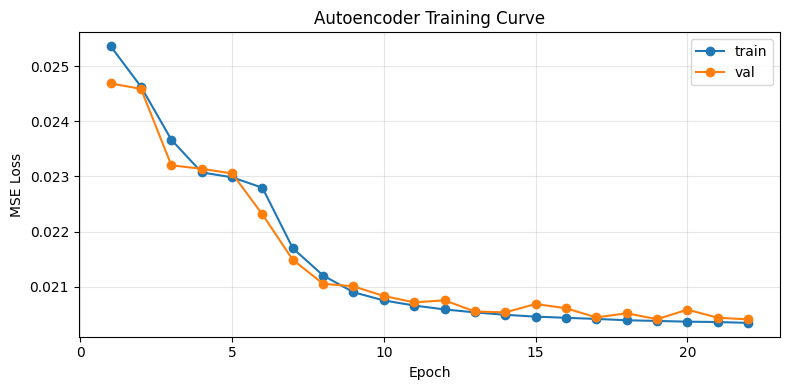

,epoch,train_loss,val_loss
17,18,0.020387,0.020514
18,19,0.020374,0.020406
19,20,0.020361,0.020579
20,21,0.020354,0.020433
21,22,0.020339,0.020402


In [8]:
history_path = REPO_ROOT / config["run"]["output_dir"] / "history.json"

if "history" in globals() and history:
    history_df = pd.DataFrame(history)
else:
    with history_path.open("r", encoding="utf-8") as f:
        history_df = pd.DataFrame(json.load(f))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
ax.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val")
ax.set_title("Autoencoder Training Curve")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

history_df.tail()


In [9]:
output_dir = REPO_ROOT / config["run"]["output_dir"]
output_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "epoch": len(history),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "config": config,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "stale_epochs": stale_epochs,
        "history": history,
    },
    output_dir / "last_model.pt",
)

if best_state_dict is not None:
    torch.save(
        {
            "epoch": best_epoch,
            "model_state_dict": best_state_dict,
            "optimizer_state_dict": optimizer.state_dict(),
            "config": config,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "stale_epochs": stale_epochs,
            "history": history,
        },
        output_dir / "best_model.pt",
    )

with (output_dir / "history.json").open("w", encoding="utf-8") as handle:
    json.dump(history, handle, indent=2)

summary = {
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "epochs_ran": len(history),
    "resumed_from": resume_from,
}
with (output_dir / "summary.json").open("w", encoding="utf-8") as handle:
    json.dump(summary, handle, indent=2)

print(f"Saved outputs to {output_dir}")
summary

Saved outputs to C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x128\autoencoder_baseline


{'best_epoch': 17,
 'best_val_loss': 0.020438190978765487,
 'epochs_ran': 22,
 'resumed_from': ''}

In [10]:
best_model_path = output_dir / "best_model.pt"
if best_model_path.exists():
    best_checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(best_checkpoint["model_state_dict"])
    print(f"Loaded best_model.pt from epoch {best_checkpoint.get('best_epoch', 'unknown')}")
else:
    print("best_model.pt not found. Using current in-memory model state.")

model.eval()

def reconstruction_error(inputs: torch.Tensor, outputs: torch.Tensor) -> torch.Tensor:
    return ((inputs - outputs) ** 2).flatten(start_dim=1).mean(dim=1)

test_rows = metadata[metadata["split"] == "test"].reset_index(drop=True)
test_scores = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        scores = reconstruction_error(inputs, outputs).cpu().numpy()
        labels = labels.cpu().numpy()
        for score, label in zip(scores, labels):
            test_scores.append({"score": float(score), "is_anomaly": int(label)})

score_df = pd.DataFrame(test_scores)
score_df.head()

Loaded best_model.pt from epoch 17


,score,is_anomaly
0,0.017056,0
1,0.032910,0
2,0.022097,0
3,0.025717,0
4,0.022751,0


In [11]:
val_scores = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        scores = reconstruction_error(inputs, outputs).cpu().numpy()
        val_scores.extend(scores.tolist())

val_score_series = pd.Series(val_scores, name="val_score")
threshold = float(val_score_series.quantile(0.95))
print(f"Chosen threshold from validation normals (95th percentile): {threshold:.6f}")
val_score_series.describe()

Chosen threshold from validation normals (95th percentile): 0.032356


count    5000.000000
mean        0.020438
std         0.007254
min         0.004228
25%         0.014850
50%         0.020103
75%         0.025712
max         0.051576
Name: val_score, dtype: float64

In [12]:
score_df["predicted_anomaly"] = (score_df["score"] > threshold).astype(int)

precision = precision_score(score_df["is_anomaly"], score_df["predicted_anomaly"], zero_division=0)
recall = recall_score(score_df["is_anomaly"], score_df["predicted_anomaly"], zero_division=0)
f1 = f1_score(score_df["is_anomaly"], score_df["predicted_anomaly"], zero_division=0)
auroc = roc_auc_score(score_df["is_anomaly"], score_df["score"])
auprc = average_precision_score(score_df["is_anomaly"], score_df["score"])
cm = confusion_matrix(score_df["is_anomaly"], score_df["predicted_anomaly"])

metrics_df = pd.DataFrame(
    [
        {"metric": "precision", "value": precision},
        {"metric": "recall", "value": recall},
        {"metric": "f1", "value": f1},
        {"metric": "auroc", "value": auroc},
        {"metric": "auprc", "value": auprc},
        {"metric": "threshold", "value": threshold},
    ]
)

display(metrics_df)
display(pd.DataFrame(cm, index=["true_normal", "true_anomaly"], columns=["pred_normal", "pred_anomaly"]))

,metric,value
0,precision,0.309973
1,recall,0.460000
2,f1,0.370370
3,auroc,0.795673
4,auprc,0.393266
5,threshold,0.032356


,pred_normal,pred_anomaly
true_normal,4744,256
true_anomaly,135,115


,threshold,precision,recall,f1,predicted_anomalies
5033,0.034747,0.462617,0.396,0.426724,213
5028,0.034680,0.456621,0.400,0.426439,218
5032,0.034717,0.460465,0.396,0.425806,214
5027,0.034665,0.454545,0.400,0.425532,219
5031,0.034701,0.458333,0.396,0.424893,215
5026,0.034636,0.452489,0.400,0.424628,220
5030,0.034695,0.456221,0.396,0.423983,216
5025,0.034596,0.450450,0.400,0.423729,221
5034,0.034754,0.460094,0.392,0.423326,212
5029,0.034682,0.454128,0.396,0.423077,217


Best F1 threshold: 0.034747 | precision=0.4626, recall=0.3960, f1=0.4267


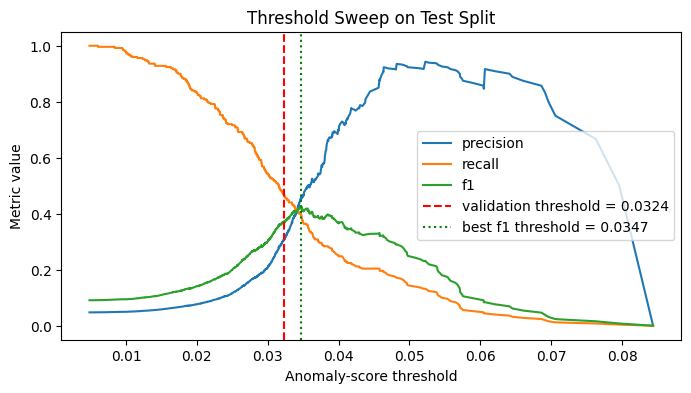

In [13]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    score_df["is_anomaly"],
    score_df["score"],
)

threshold_sweep_df = pd.DataFrame(
    {
        "threshold": pr_thresholds,
        "precision": precision_curve[:-1],
        "recall": recall_curve[:-1],
    }
)

threshold_sweep_df["f1"] = (
    2
    * threshold_sweep_df["precision"]
    * threshold_sweep_df["recall"]
    / (threshold_sweep_df["precision"] + threshold_sweep_df["recall"] + 1e-12)
)

threshold_sweep_df["predicted_anomalies"] = [
    int((score_df["score"] > t).sum()) for t in threshold_sweep_df["threshold"]
]

best_f1_row = threshold_sweep_df.loc[threshold_sweep_df["f1"].idxmax()]

display(threshold_sweep_df.sort_values("f1", ascending=False).head(10))
print(
    f"Best F1 threshold: {best_f1_row['threshold']:.6f} | "
    f"precision={best_f1_row['precision']:.4f}, recall={best_f1_row['recall']:.4f}, f1={best_f1_row['f1']:.4f}"
)

plt.figure(figsize=(8, 4))
plt.plot(threshold_sweep_df["threshold"], threshold_sweep_df["precision"], label="precision")
plt.plot(threshold_sweep_df["threshold"], threshold_sweep_df["recall"], label="recall")
plt.plot(threshold_sweep_df["threshold"], threshold_sweep_df["f1"], label="f1")
plt.axvline(threshold, color="red", linestyle="--", label=f"validation threshold = {threshold:.4f}")
plt.axvline(best_f1_row["threshold"], color="green", linestyle=":", label=f"best f1 threshold = {best_f1_row['threshold']:.4f}")
plt.xlabel("Anomaly-score threshold")
plt.ylabel("Metric value")
plt.title("Threshold Sweep on Test Split")
plt.legend()
plt.show()


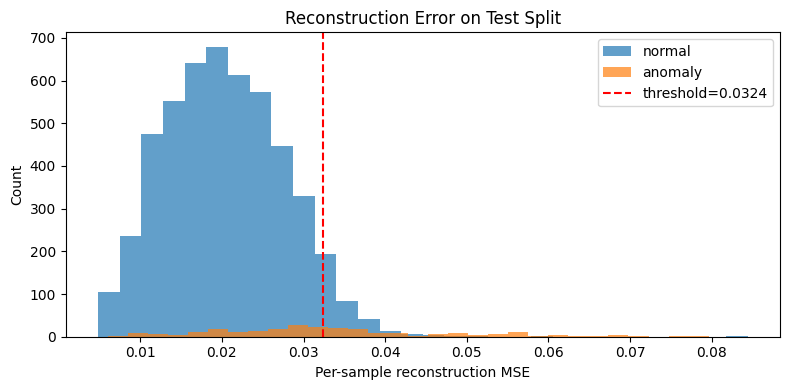

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(score_df[score_df["is_anomaly"] == 0]["score"], bins=30, alpha=0.7, label="normal")
ax.hist(score_df[score_df["is_anomaly"] == 1]["score"], bins=30, alpha=0.7, label="anomaly")
ax.axvline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.4f}")
ax.set_title("Reconstruction Error on Test Split")
ax.set_xlabel("Per-sample reconstruction MSE")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()

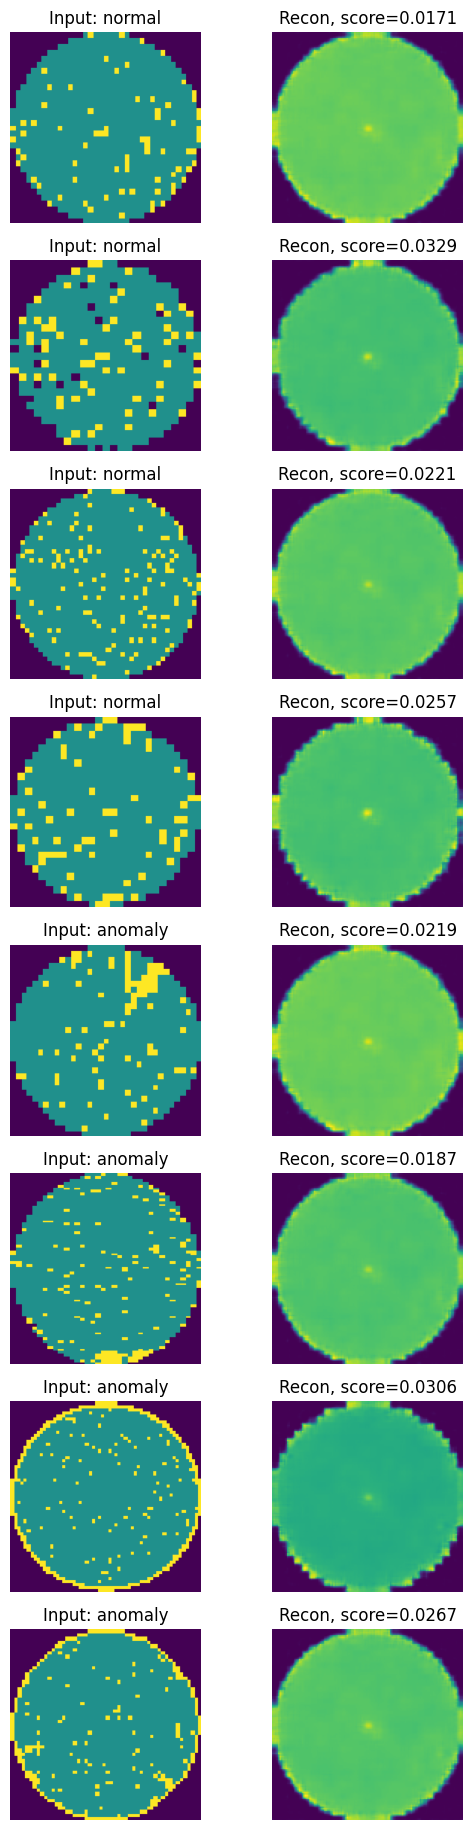

In [15]:
normal_test_idx = score_df[score_df["is_anomaly"] == 0].index[:4].tolist()
anomaly_test_idx = score_df[score_df["is_anomaly"] == 1].index[:4].tolist()
selected_indices = normal_test_idx + anomaly_test_idx

fig, axes = plt.subplots(len(selected_indices), 2, figsize=(6, 2.3 * len(selected_indices)))

with torch.no_grad():
    for row_idx, sample_idx in enumerate(selected_indices):
        input_tensor, label = test_dataset[sample_idx]
        output_tensor = model(input_tensor.unsqueeze(0).to(device)).squeeze(0).cpu()
        title_prefix = "anomaly" if int(label) == 1 else "normal"
        score = score_df.iloc[sample_idx]["score"]

        axes[row_idx, 0].imshow(input_tensor.squeeze(0), cmap="viridis")
        axes[row_idx, 0].set_title(f"Input: {title_prefix}")
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(output_tensor.squeeze(0), cmap="viridis")
        axes[row_idx, 1].set_title(f"Recon, score={score:.4f}")
        axes[row_idx, 1].axis("off")

plt.tight_layout()